In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv("final_combined_data.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Ticker,Return,Volatility,Volume_Zscore,Return_Zscore,Manipulation_Flag,stock,sentiment_score,risk_score,event_count,twitter_sentiment
0,2018-01-02,39.986349,40.489233,39.774854,40.479832,102223600,AAPL,NaN,NaN,-0.092570,NaN,0,AAPL,0.5,1.0,0.0,0.5
1,2018-01-03,40.543277,41.017963,40.409333,40.472778,118071600,AAPL,-0.000174,NaN,0.194878,-0.070361,0,AAPL,0.5,1.0,0.0,0.5
2,2018-01-04,40.545623,40.764168,40.437528,40.660770,89738400,AAPL,0.004645,NaN,-0.319025,0.171144,0,AAPL,0.5,1.0,0.0,0.5
3,2018-01-05,40.757138,41.210672,40.665491,41.123726,94640000,AAPL,0.011386,NaN,-0.230121,0.508955,0,AAPL,0.5,1.0,0.0,0.5
4,2018-01-08,40.970982,41.267071,40.872282,40.970982,82271200,AAPL,-0.003714,NaN,-0.454464,-0.247764,0,AAPL,0.5,1.0,0.0,0.5


In [3]:
print("\nMissing Values per Column:\n", df.isnull().sum())


Missing Values per Column:
 Date                  0
Open                  0
High                  0
Low                   0
Close                 0
Volume                0
Ticker                0
Return                9
Volatility           63
Volume_Zscore         0
Return_Zscore         9
Manipulation_Flag     0
stock                 0
sentiment_score       0
risk_score            0
event_count           0
twitter_sentiment     0
dtype: int64


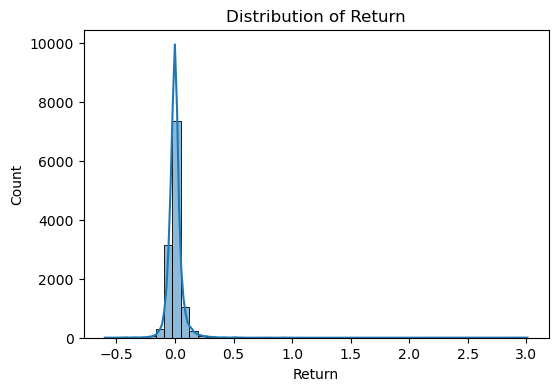

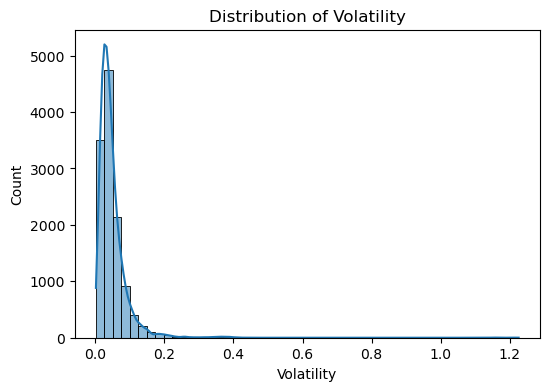

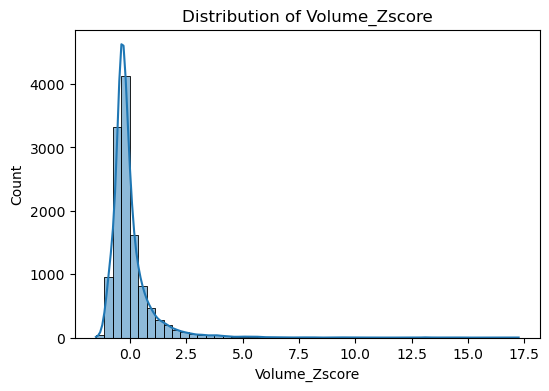

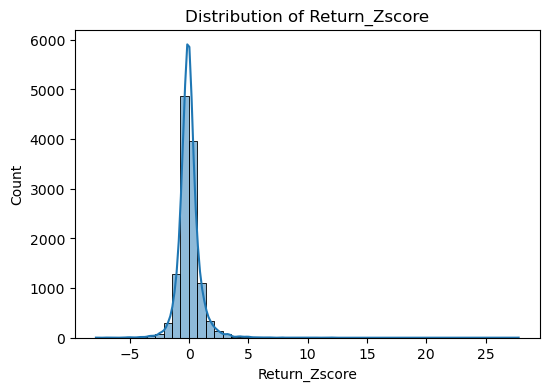

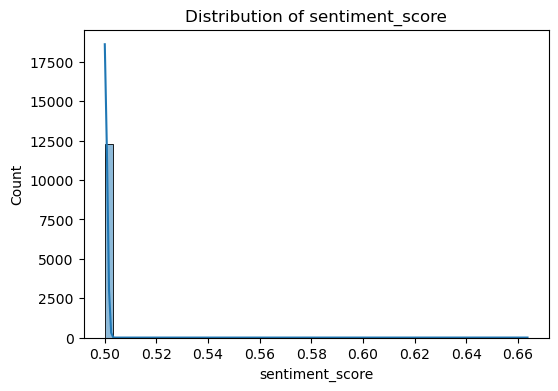

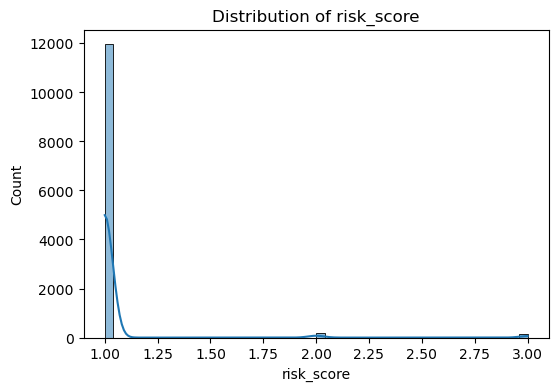

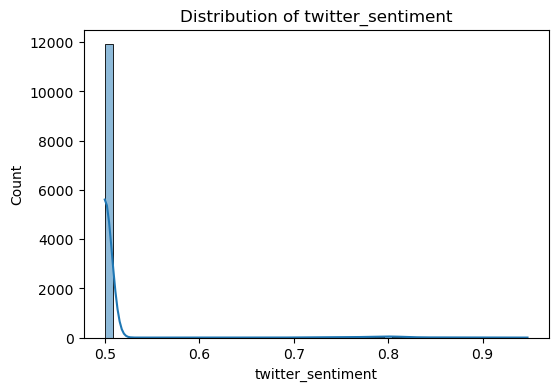

In [4]:
numeric_cols = ['Return', 'Volatility', 'Volume_Zscore', 'Return_Zscore', 'sentiment_score', 'risk_score', 'twitter_sentiment']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

Manipulation_Flag
0    12236
1       60
Name: count, dtype: int64


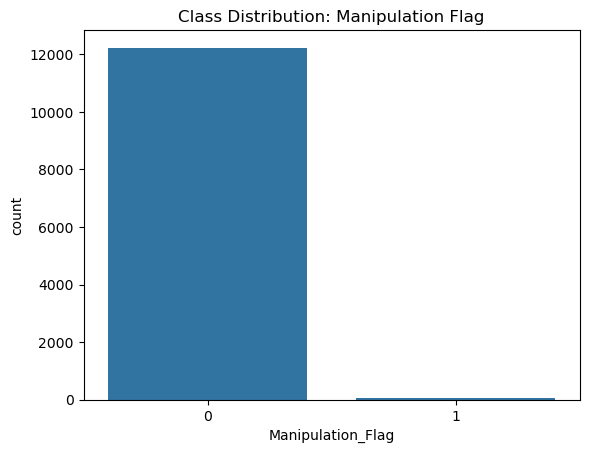

In [5]:
print(df['Manipulation_Flag'].value_counts())
sns.countplot(x='Manipulation_Flag', data=df)
plt.title('Class Distribution: Manipulation Flag')
plt.show()

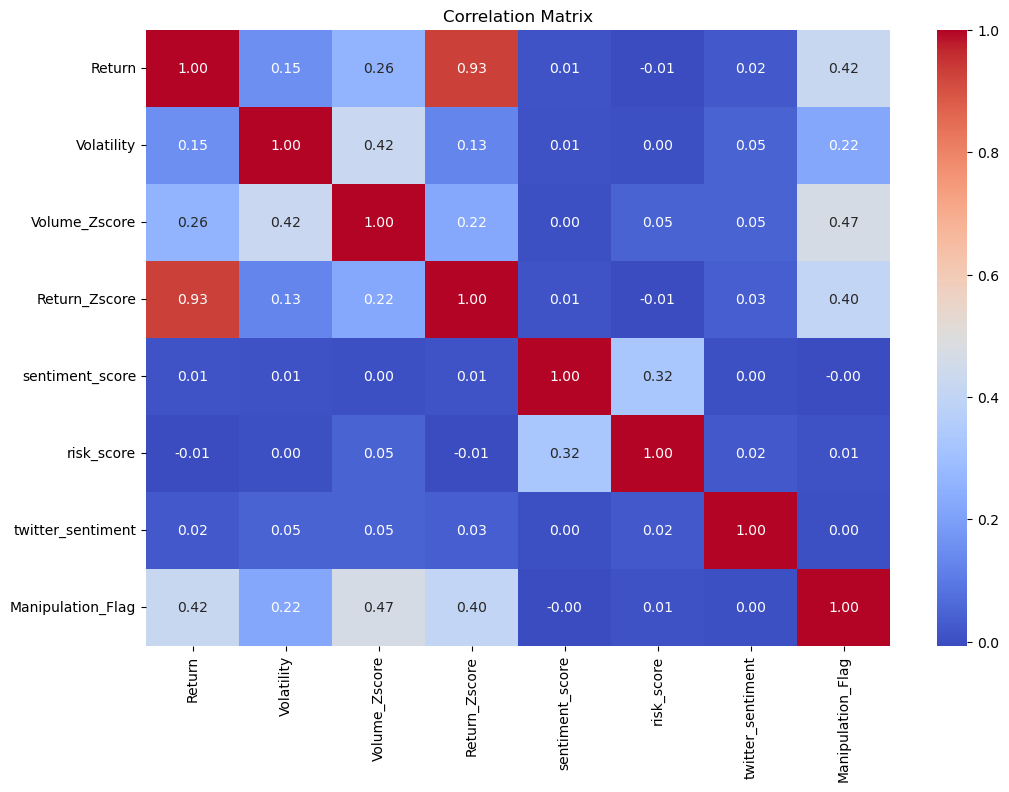

In [6]:
plt.figure(figsize=(12,8))
corr = df[numeric_cols + ['Manipulation_Flag']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

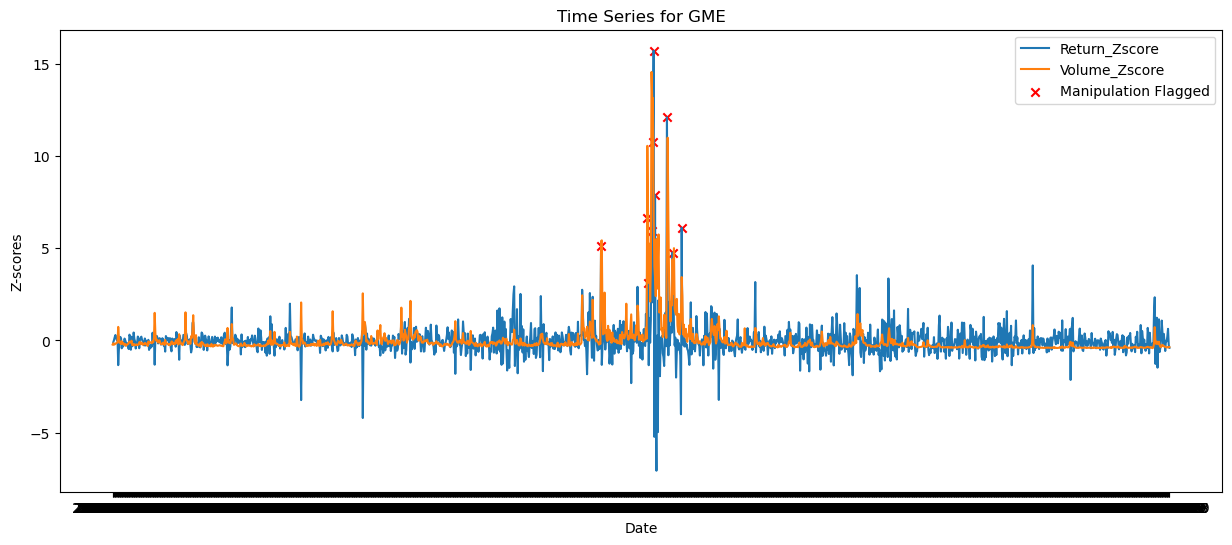

In [8]:
sample_stock = 'GME'
sample_df = df[df['stock'] == sample_stock]

plt.figure(figsize=(15,6))
plt.plot(sample_df['Date'], sample_df['Return_Zscore'], label='Return_Zscore')
plt.plot(sample_df['Date'], sample_df['Volume_Zscore'], label='Volume_Zscore')
plt.scatter(sample_df['Date'][sample_df['Manipulation_Flag']==1],
            sample_df['Return_Zscore'][sample_df['Manipulation_Flag']==1],
            color='red', label='Manipulation Flagged', marker='x')
plt.legend()
plt.title(f'Time Series for {sample_stock}')
plt.xlabel('Date')
plt.ylabel('Z-scores')
plt.show()